In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [2]:
import numpy as np
from quri_parts.circuit import LinearMappedUnboundParametricQuantumCircuit
from quri_parts.core.state import quantum_state

n = 4 #頂点の数

def add_U_C(circuit, gamma_idx):
    gamma = circuit.add_parameter(f"gamma_{gamma_idx}")
    for i in range(n):
        j = (i+1) % n
        circuit.add_CNOT_gate(i, j)
        circuit.add_ParametricRZ_gate(j, {gamma: 2})
        circuit.add_CNOT_gate(i, j)

def add_U_X(circuit, beta_idx):
    beta = circuit.add_parameter(f"beta_{beta_idx}")
    for i in range(n):
        circuit.add_ParametricRX_gate(i, {beta: 2})
    return circuit

def QAOA_state(x: list[float], p: int):
    # 変分量子回路を作成
    circuit = LinearMappedUnboundParametricQuantumCircuit(n)
    # |s>を作成
    for i in range(n):
        circuit.add_H_gate(i)
    # U_C, U_Xをp回適用
    for i in range(p):
        add_U_C(circuit, i)
        add_U_X(circuit, i)
    # パラメータが代入された回路を作成
    bound_circuit = circuit.bind_parameters(x)
    # 変分量子状態を作成
    return quantum_state(n, circuit=bound_circuit)

In [3]:
from quri_parts.core.operator import Operator, pauli_label
from quri_parts.qulacs.estimator import create_qulacs_vector_estimator

cost_observable = Operator({pauli_label(f"Z{i} Z{(i+1) % n}"): 0.5 for i in range(n)})
estimator = create_qulacs_vector_estimator()
def QAOA_cost_func(x: list[float], p: int) -> float:
  state = QAOA_state(x, p)
  return estimator(cost_observable, state).value.real

In [4]:
from scipy.optimize import minimize
p = 1 # QAOA の層数
x0 = np.array( [0.1] * (2*p) ) # 初期パラメータ
result = minimize(QAOA_cost_func, x0, args=(p), method='Powell')
print("QAOA Cost:", result.fun) # 最適化後のコスト関数の値
print("Optimized Parameter:", result.x) # 最適化されたパラメータ

QAOA Cost: -0.9999999994991837
Optimized Parameter: [1.17809152 0.39269362]


[0.01562503 0.01562428 0.01562428 0.0781264  0.01562428 0.26562503
 0.0781264  0.01562428 0.01562428 0.0781264  0.26562503 0.01562428
 0.0781264  0.01562428 0.01562428 0.01562503]


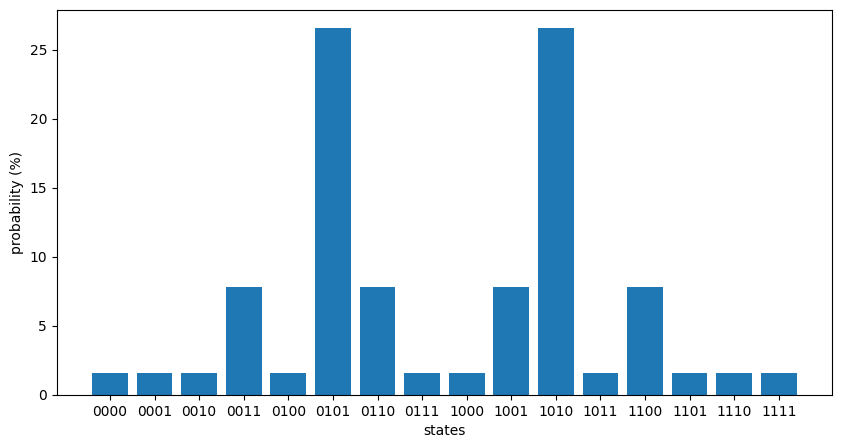

In [5]:
# 最適化されたパラメータを用いて状態を作成し, 各測定結果が得られる確率を求める
from quri_parts.qulacs.simulator import evaluate_state_to_vector
state_vec = evaluate_state_to_vector(QAOA_state(result.x, p)).vector
probs = np.abs(state_vec)**2
print(probs)

# プロット
import matplotlib.pyplot as plt
z_basis = [format(i,"b").zfill(n) for i in range(probs.size)] # 整数をビット列に変換
plt.figure(figsize=(10, 5))
plt.xlabel("states")
plt.ylabel("probability (%)")
plt.bar(z_basis, probs*100)
plt.show()

QAOA Cost: -1.9999992381341447
Optimized parameters: [ 1.11854459  0.55939778 -2.12994593  0.4523998 ]
[1.52474692e-15 2.21896542e-08 2.21896542e-08 5.08539216e-08
 2.21896542e-08 4.99999810e-01 5.08539216e-08 2.21896542e-08
 2.21896542e-08 5.08539216e-08 4.99999810e-01 2.21896542e-08
 5.08539216e-08 2.21896542e-08 2.21896542e-08 1.52474692e-15]


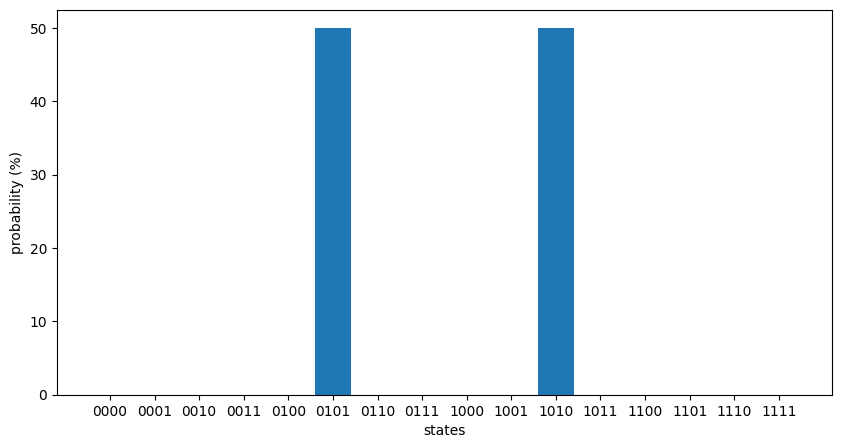

In [6]:
p = 2 # QAOA の層数を2 に設定
x0 = np.array([0.1] * (2 * p)) # 初期パラメータ

result = minimize(QAOA_cost_func, x0, args=(p), method='Powell')
print("QAOA Cost:", result.fun)
print("Optimized parameters:", result.x)

from quri_parts.qulacs.simulator import evaluate_state_to_vector
state_vec = evaluate_state_to_vector(QAOA_state(result.x, p)).vector
probs = np.abs(state_vec)**2
print(probs)

plt.figure(figsize=(10, 5))
plt.xlabel("states")
plt.ylabel("probability (%)")
plt.bar(z_basis, probs*100)
plt.show()